In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

from pathlib import Path
import re


from jupyters.visu_utils import load_sts_merged_mteb, load_clustering_merged_mteb, load_classification_merged_mteb
from visu_utils import TASK_LIST_CLASSIFICATION, make_results_tables_per_group_size, load_sts_merged_mteb

from autorank import autorank, plot_stats, create_report, latex_table

EXPORT_PATH_TABLE = Path("../../papers/Distillation-MI-ICLR/tables/nlp/")
EXPORT_PATH_FIG = Path("../../papers/Distillation-MI-ICLR/figures/nlp/")

# Make sure the folders exist
EXPORT_PATH_TABLE.mkdir(parents=True, exist_ok=True)
EXPORT_PATH_FIG.mkdir(parents=True, exist_ok=True)

%reload_ext autoreload
%autoreload 2


In [9]:

MTEB_BASELINES_PATH_STS = Path("../non_sync/baselines_mteb/mteb_detailed/en_STS.csv")

MTEB_BASELINES_PATH_CLASSIFICATION = Path("../non_sync/baselines_mteb/mteb_detailed/en_Classification.csv")

MTEB_BASELINES_PATH_CLUSTERING = Path("../non_sync/baselines_mteb/mteb_detailed/en_Clustering.csv")

RESULTS_PATHS = [Path("../non_sync/mteb_benchmarking/results/experiments_gist_nll"),
                 Path("../non_sync/mteb_benchmarking/results/experiments_gist_mse")
                 ]



df_merged_sts = load_sts_merged_mteb(MTEB_BASELINES_PATH_STS, RESULTS_PATHS)

df_merged_sts = df_merged_sts[
    (df_merged_sts['Model Size (Million Parameters)'] >= 10) & (df_merged_sts['Model Size (Million Parameters)'] <= 110)]

# select only last training step for each model
df_merged = df_merged_sts.reset_index()

indices = df_merged_sts.sort_values('Training step').groupby('Model')['Training step'].idxmax()
df_merged_sts = df_merged_sts.loc[indices]
df_merged_sts = df_merged_sts.drop('Training step', axis=1)


df_melted_sts = df_merged_sts.melt(id_vars=['Model', 'Model Size (Million Parameters)', 'loss', 'Dataset'],
                           value_vars=df_merged_sts.columns[4:], var_name='Task', value_name='Score')


df_melted_sts = df_melted_sts[~df_melted_sts['Task'].str.contains('SummEval')]



In [10]:
df_merged_clustering = load_clustering_merged_mteb(MTEB_BASELINES_PATH_CLUSTERING, RESULTS_PATHS)

df_merged_clustering = df_merged_clustering[
    (df_merged_clustering['Model Size (Million Parameters)'] >= 10) & (
                df_merged_clustering['Model Size (Million Parameters)'] <= 110)]

# select only last training step for each model
df_merged_clustering = df_merged_clustering.reset_index()

indices = df_merged_clustering.sort_values('Training step').groupby('Model')['Training step'].idxmax()
df_merged_clustering = df_merged_clustering.loc[indices]
df_merged_clustering = df_merged_clustering.drop('Training step', axis=1)



df_melted_clustering = df_merged_clustering.melt(id_vars=['Model', 'Model Size (Million Parameters)', 'loss', 'Dataset'],
                                                 value_vars=df_merged_clustering.columns[4:], var_name='Task', value_name='Score')




In [11]:

# df_merged = load_classification_merged_mteb(MTEB_BASELINES_PATH, RESULTS_PATHS)
# 
# df_merged = df_merged[
#     (df_merged['Model Size (Million Parameters)'] >= 10) & (df_merged['Model Size (Million Parameters)'] <= 450)]
# 
# # select only last training step for each model
# df_merged = df_merged.reset_index()
# 
# indices = df_merged.sort_values('Training step').groupby('Model')['Training step'].idxmax()
# 
# df_merged = df_merged.loc[indices]
# df_merged = df_merged.drop('Training step', axis=1)

# rewrite for df_merged_classification

df_merged_classification = load_classification_merged_mteb(MTEB_BASELINES_PATH_CLASSIFICATION, RESULTS_PATHS)

df_merged_classification = df_merged_classification[
    (df_merged_classification['Model Size (Million Parameters)'] >= 10) & (
                df_merged_classification['Model Size (Million Parameters)'] <= 110)]

# select only last training step for each model
df_merged_classification = df_merged_classification.reset_index()

indices = df_merged_classification.sort_values('Training step').groupby('Model')['Training step'].idxmax()
df_merged_classification = df_merged_classification.loc[indices]
df_merged_classification = df_merged_classification.drop('Training step', axis=1)



df_melted_classification = df_merged_classification.melt(id_vars=['Model', 'Model Size (Million Parameters)', 'loss', 'Dataset'],
                           value_vars=df_merged_classification.columns[4:], var_name='Task', value_name='Accuracy')


In [25]:


def pareto_plot(df_melted, ax, xlim, ylim, metric='Accuracy', legend=False):

    df_avg = df_melted.groupby(['Model', 'loss']).mean(numeric_only=True)
    df_avg = df_avg.reset_index()

    # rename loss
    df_avg['loss'] = df_avg['loss'].replace({"N/A": "MTEB"})
    # rename column loss
    df_avg = df_avg.rename(columns={"loss": "Models"})

    # keep only less than 50M 
    df_avg = df_avg[df_avg['Model Size (Million Parameters)'] <= 120]
    df_avg = df_avg.dropna()

    def trace_pareto_frontier(df, x, y, ax):
        df = df.sort_values(x)
        pareto_front = [df.iloc[0]]
        for i in range(1, len(df)):
            if df.iloc[i][y] >= pareto_front[-1][y]:
                pareto_front.append(df.iloc[i])
        pareto_front = pd.DataFrame(pareto_front)
        ax.plot(pareto_front[x], pareto_front[y], 'crimson', linestyle="-.", lw=1, alpha=0.3)
        # fill below
        ax.fill_between(pareto_front[x], pareto_front[y], 0, alpha=0.1, color='red')

    df_avg = df_avg.sort_values('Models')
    trace_pareto_frontier(df_avg, 'Model Size (Million Parameters)', metric, ax)
    sns.scatterplot(data=df_avg, x='Model Size (Million Parameters)', y=metric, hue='Models', size="Models", hue_order=['MTEB', 'MSE', 'NLL'],
                    sizes=(170, 10), ax=ax, palette="husl", style='Models', markers=True, size_order=['MTEB', 'MSE', 'NLL'])


    # move ax legend outside
    if legend:
        sns.move_legend(ax, "lower center")
    else:
        ax.get_legend().remove()

    # Change label sizes
    ax.set_xlabel("Model Size (M)", fontsize=10) # fontweight='bold')
    ax.set_ylabel("", fontsize=10) #, fontweight='bold')


    # set ylim
    if ylim:
        ax.set_ylim(*ylim)
    if xlim:
        ax.set_xlim(*xlim)
        
    
        


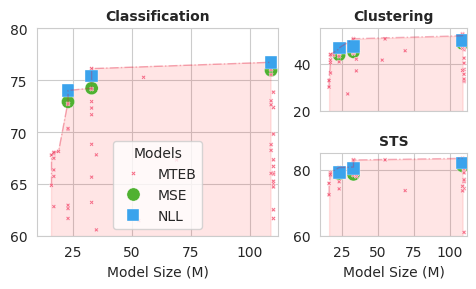

In [26]:

mosaic = [
    ['A', 'A', 'A', 'B', 'B'],
    ['A', 'A', 'A', 'B', 'B'], 
    ['A', 'A', 'A', 'C', 'C'],
    ['A', 'A', 'A', 'C', 'C'], 
          ]

# A : classification
# B : clustering
# C : sts
sns.set_style("whitegrid")
fig, axes = plt.subplot_mosaic(mosaic, figsize=(5, 3), sharex=True)

pareto_plot(df_melted_classification, axes['A'], xlim=(10, 111), ylim=(60, 80), legend=True)
axes['A'].set_title("Classification", fontsize=10, fontweight='bold')

pareto_plot(df_melted_clustering, axes['B'], xlim=(10, 112), ylim=(20, 55), metric='Score', legend=False)
axes['B'].set_title("Clustering", fontsize=10, fontweight='bold')

pareto_plot(df_melted_sts, axes['C'], xlim=(10, 112), ylim=(60, 85), metric="Score", legend=False)
axes['C'].set_title("STS", fontsize=10, fontweight='bold')

fig.tight_layout()

fig.savefig(EXPORT_PATH_FIG / "pareto_frontier_packed_less_110.png")
